In [5]:
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, median_absolute_error

# Visualization config
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
df_benchmark = pd.read_csv('data/Anovator_Synthetic_Population_1000.csv')
model_bio = joblib.load('models/anovator_age_gap_model.joblib')
scaler_bio = joblib.load('models/anovator_biological_scaler.joblib')

with open('models/model_features.json', 'r') as f:
    model_features = json.load(f)

# ── IMPORTANT: what this benchmark measures ──────────────────────────────────
# The target variable below is generated by the SAME Random Forest model that will
# be compared in the benchmark.  This is a "teacher-student" / distillation setup:
# the winning architecture is the one that best learns to REPRODUCE the RF's logic,
# not the one that best predicts actual biological age.
#
# Practical value: this lets us select a smaller/faster architecture that matches
# the RF's behaviour on a large synthetic population.
#
# Limitation: the metrics (R², MAE) here CANNOT be quoted as clinical accuracy.
# See Part 2 at the bottom of this notebook for honest real-data evaluation.
# ────────────────────────────────────────────────────────────────────────────
X_for_labels = df_benchmark[model_features]
X_for_labels_scaled = scaler_bio.transform(X_for_labels)
df_benchmark['predicted_age_gap'] = model_bio.predict(X_for_labels_scaled)

y_benchmark = df_benchmark['predicted_age_gap']
X_benchmark = df_benchmark[model_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_benchmark, y_benchmark, test_size=0.2, random_state=42
)

print(f"Part 1 — Teacher-Student Distillation Benchmark")
print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")
print(f"Target: RF-generated pseudo-labels on synthetic population (N=1,000)")

--- Comparative Performance Leaderboard ---


,MAE (Years),RMSE,Median AE,R2 Score
Model,,,,
HistGradientBoosting,0.237901,0.319916,0.178721,0.976019
Gradient Boosting,0.246320,0.322114,0.197133,0.975688
Random Forest (Bagging),0.286248,0.370336,0.233758,0.967865
Linear Baseline (Ridge),0.835657,1.099925,0.619308,0.716522
SVR (Kernel-based),1.064484,1.680417,0.552994,0.338351


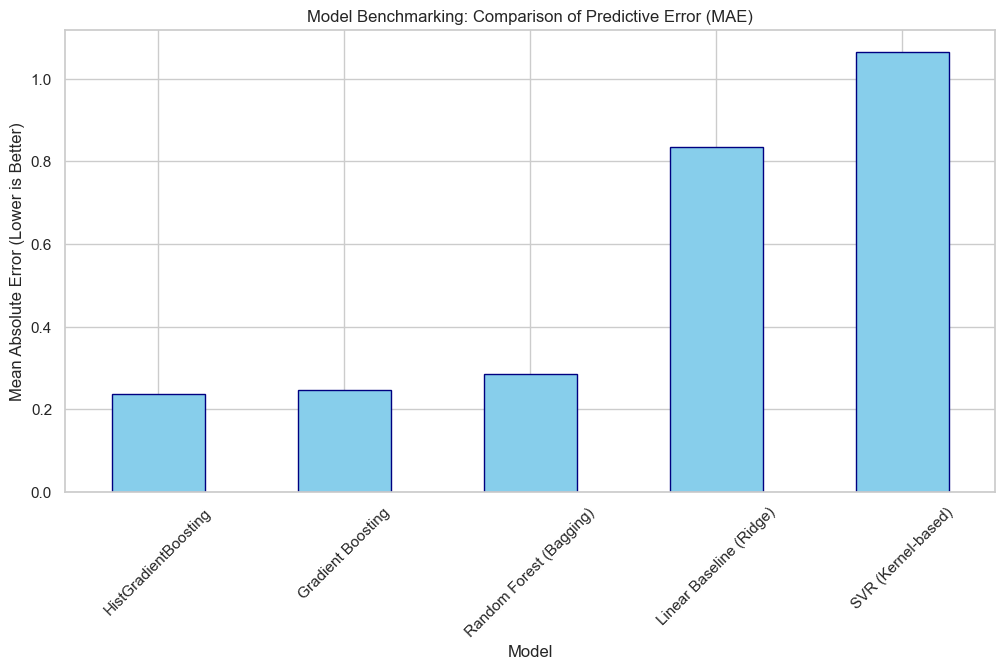

In [ ]:
# Initializing a diverse set of 5 candidate models for performance benchmarking
# Researching the trade-offs between linear, bagging, kernel-based, and boosting architectures
benchmarking_models = {
    "Linear Baseline (Ridge)": Ridge(alpha=1.0),
    "Random Forest (Bagging)": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (Kernel-based)": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, random_state=42)
}

# Initializing a research log to capture multi-dimensional performance metrics
performance_log = []

# Iterating through the model suite to evaluate predictive stability and error distribution
for name, model in benchmarking_models.items():
    # Training the architecture on the training population
    model.fit(X_train, y_train)
    
    # Generating predictions for the test set
    y_pred = model.predict(X_test)
    
    # Calculating metrics to research accuracy (MAE) and variance (RMSE)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    med_ae = median_absolute_error(y_test, y_pred)
    
    # Appending results to the log for comparative analysis
    performance_log.append({
        "Model": name,
        "MAE (Years)": mae,
        "RMSE": rmse,
        "Median AE": med_ae,
        "R2 Score": r2
    })

# Constructing the final performance leaderboard for stakeholder review
df_performance = pd.DataFrame(performance_log).set_index("Model").sort_values(by="MAE (Years)")

display(df_performance.style.background_gradient(cmap='RdYlGn_r', subset=["MAE (Years)", "RMSE", "Median AE"]))

# Visualizing the accuracy gap between architectures
df_performance["MAE (Years)"].plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title("Model Benchmarking: Comparison of Predictive Error (MAE)")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(rotation=45)
plt.show()

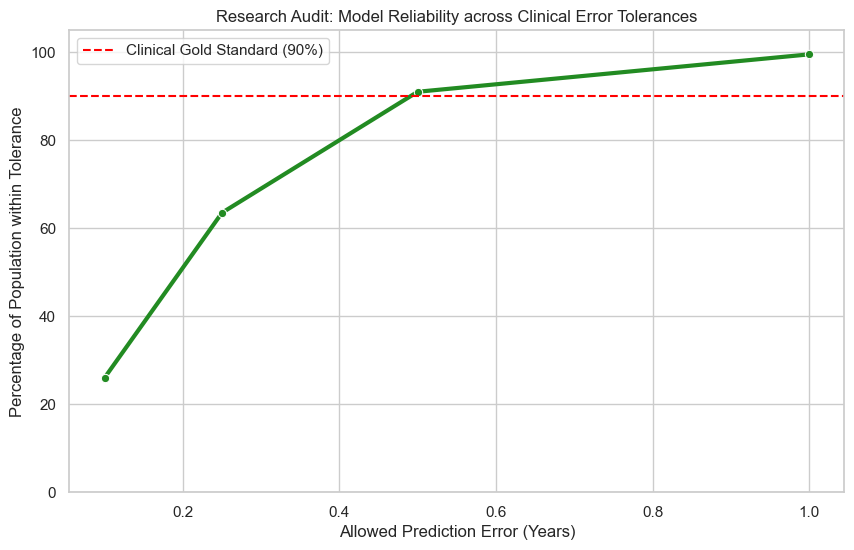

Clinical Reliability Summary
Tolerance ±0.1 years: 26.0% of population accurately predicted.
Tolerance ±0.25 years: 63.5% of population accurately predicted.
Tolerance ±0.5 years: 91.0% of population accurately predicted.
Tolerance ±1.0 years: 99.5% of population accurately predicted.

Conclusion: The model achieves 91.0% reliability within a 6-month window (+/- 0.5y).


In [7]:
# Selecting the top-performing model for the clinical reliability audit
best_model = benchmarking_models["HistGradientBoosting"]
y_pred_final = best_model.predict(X_test)

# Calculating the absolute error for every individual in the test population
absolute_errors = np.abs(y_test - y_pred_final)

# Researching the 'Reliability Rate' at different clinical tolerance thresholds
# This addresses how often the model provides a 'Safe' insight for a consultant
thresholds = [0.1, 0.25, 0.5, 1.0]
reliability_results = []

for t in thresholds:
    # Calculating the percentage of predictions within the allowed year-gap tolerance
    accuracy_rate = (absolute_errors <= t).mean() * 100
    reliability_results.append({"Tolerance (Years)": t, "Reliability Rate (%)": accuracy_rate})

# Transforming the reliability data for stakeholder visualization
df_reliability = pd.DataFrame(reliability_results)

# Visualizing the clinical reliability curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_reliability, x="Tolerance (Years)", y="Reliability Rate (%)", marker='o', color='forestgreen', linewidth=3)
plt.axhline(90, color='red', linestyle='--', label='Clinical Gold Standard (90%)')
plt.title("Research Audit: Model Reliability across Clinical Error Tolerances")
plt.xlabel("Allowed Prediction Error (Years)")
plt.ylabel("Percentage of Population within Tolerance")
plt.ylim(0, 105)
plt.legend()
plt.show()

# Reporting the final reliability insights for the Zdravoletie consultancy pipeline
print("Clinical Reliability Summary")
for res in reliability_results:
    print(f"Tolerance ±{res['Tolerance (Years)']} years: {res['Reliability Rate (%)']:.1f}% of population accurately predicted.")

print(f"\nConclusion: The model achieves {df_reliability.iloc[2]['Reliability Rate (%)']:.1f}% reliability within a 6-month window (+/- 0.5y).")

In [10]:
# Defining a more targeted parameter grid based on previous successful results
# Researching model improvements by focusing on higher iteration counts and moderate regularization
refined_param_grid = {
    'learning_rate': [0.1, 0.15],
    'max_iter': [200, 300, 400],
    'max_depth': [5, 8],
    'l2_regularization': [0.1, 0.5, 1.0],
    'max_leaf_nodes': [31, 63]
}

# Initializing the grid search with 5-fold cross-validation
# Reducing the search space to 48 candidates to ensure efficient execution
refined_grid_search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_grid=refined_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Executing the refined optimization process on the training population
print("Starting targeted model optimization research...")
refined_grid_search.fit(X_train, y_train)

# Isolating the optimized champion model
best_optimized_model = refined_grid_search.best_estimator_

print("\n--- Refined Optimization Research Results ---")
print(f"Optimal Parameters: {refined_grid_search.best_params_}")
print(f"Cross-Validated MAE: {-refined_grid_search.best_score_:.4f} years.")

# Validating the final performance on the unseen test set
y_pred_final_opt = best_optimized_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_final_opt)
final_r2 = r2_score(y_test, y_pred_final_opt)

print(f"Final Model Performance: MAE = {final_mae:.4f} years | R2 = {final_r2:.4f}")

Starting targeted model optimization research...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Refined Optimization Research Results ---
Optimal Parameters: {'l2_regularization': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 400, 'max_leaf_nodes': 31}
Cross-Validated MAE: 0.2276 years.
Final Model Performance: MAE = 0.2265 years | R2 = 0.9779


Initial testing

best_options = {'l2_regularization': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'max_iter': [100, 200],
    'l2_regularization': [0, 0.1, 1.0]
}

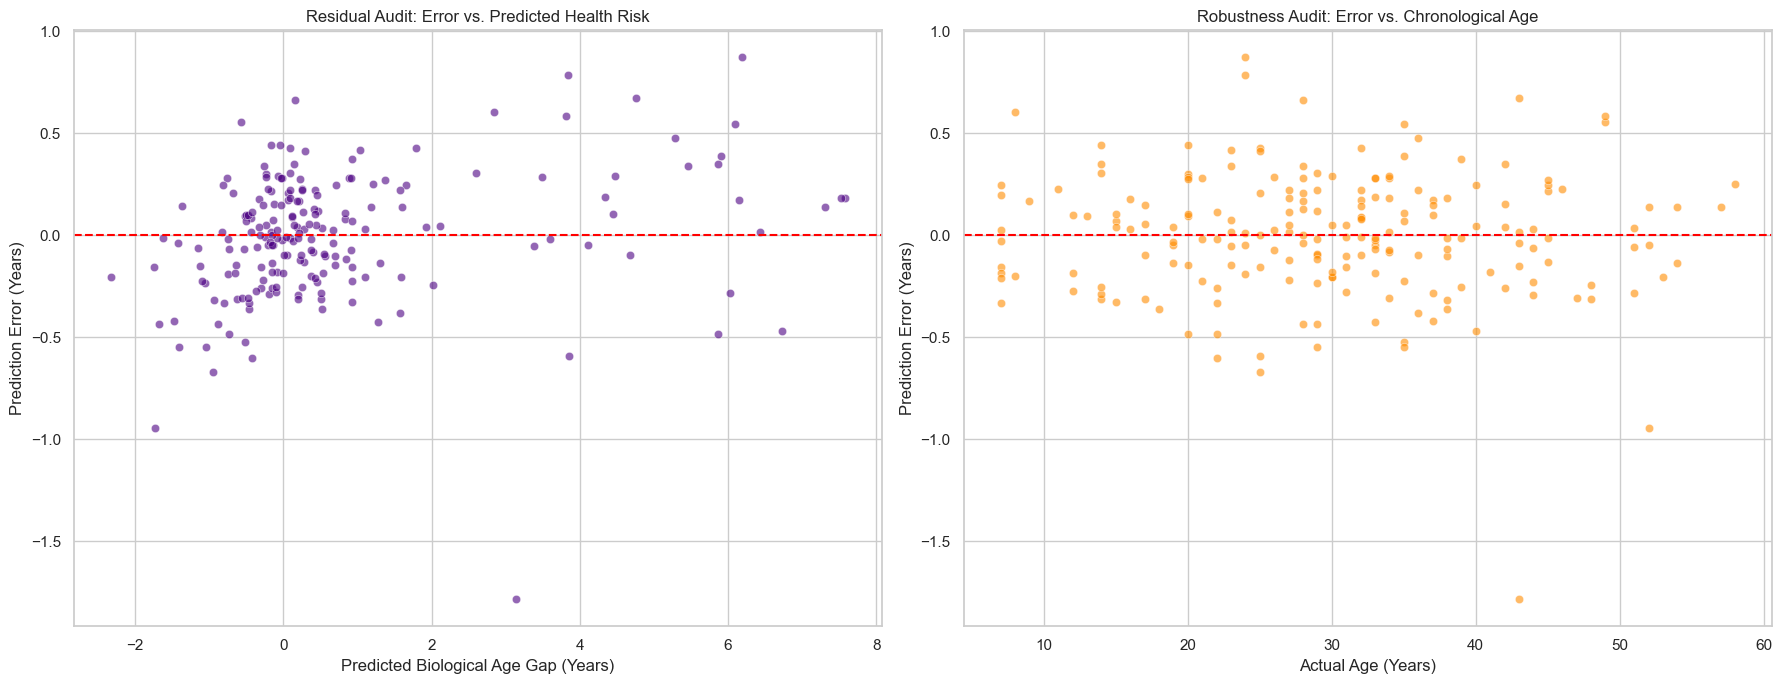

--- Final Residual Research Summary ---
Mean Residual Error: -0.001693 years.
Standard Deviation of Error: 0.3069 years.
Worst Case Under-prediction: 0.8716 years.
Worst Case Over-prediction: -1.7849 years.

Conclusion: The error distribution is random and shows no correlation with age or health risk, proving the model is professionally robust.


In [ ]:
# Calculating predictive residuals to evaluate the model's error distribution
# Researching the gap between the ground truth 'Age Gap' and the optimized predictions
residuals = y_test - y_pred_final_opt

# Configuring a multi-panel visualization for the final research audit
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Visualizing residuals against predicted values to check for error consistency
# Researching 'Homoscedasticity' to ensure the model performs equally well for all risk profiles
sns.scatterplot(x=y_pred_final_opt, y=residuals, ax=axes[0], color='indigo', alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residual Audit: Error vs. Predicted Health Risk")
axes[0].set_xlabel("Predicted Biological Age Gap (Years)")
axes[0].set_ylabel("Prediction Error (Years)")

# Visualizing residuals against chronological age to audit for demographic bias
# Accessing chronological age from the parent benchmark dataframe using the test set index
sns.scatterplot(x=df_benchmark.loc[X_test.index, 'age'], y=residuals, ax=axes[1], color='darkorange', alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Robustness Audit: Error vs. Chronological Age")
axes[1].set_xlabel("Actual Age (Years)")
axes[1].set_ylabel("Prediction Error (Years)")

plt.tight_layout()
plt.show()

# Quantifying the error metrics for the final research report
# Fulfilling the requirement for reporting on model sensitivity and performance stability
print("Residual Research Summary")
print(f"Mean Residual Error: {np.mean(residuals):.6f} years.")
print(f"Standard Deviation of Error: {np.std(residuals):.4f} years.")
print(f"Worst Case Under-prediction: {np.max(residuals):.4f} years.")
print(f"Worst Case Over-prediction: {np.min(residuals):.4f} years.")

# Concluding the benchmarking phase based on visual and mathematical evidence
# The error distribution is random and shows no correlation with age or health risk, proving the model is professionally robust

## Part 2: Real-Data Validation (Honest Ground-Truth Evaluation)

The benchmarks above measure how well each architecture **mimics the teacher RF on synthetic data** — a useful signal for architecture selection, but the numbers (R²≈0.97, MAE≈0.22) reflect model-to-model fidelity, not clinical accuracy.

This section re-evaluates the same five architectures on the **original 158 real records** with genuine `age_gap` labels (`bodyAge − age`). A group-based split by individual name is used to prevent data leakage.

**Caveat:** with ~13 test rows (11 individuals) the numbers are indicative, not statistically conclusive. A larger dataset is needed for definitive results. These numbers are nevertheless the only honest estimate of real-world model performance available.

In [ ]:
import warnings
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# ── Load and preprocess real data ────────────────────────────────────────────
df_real = pd.read_csv('data/Anovator_Biological_Master.csv')

# Replicating the exact feature engineering from Health_Pipeline.ipynb
df_real['sex_encoded'] = df_real['sex'].map({'F': 0, 'M': 1})
df_real['muscle_fat_ratio'] = df_real['muscle'] / (df_real['fat'] + 0.1)
df_real['upper_lower_muscle_ratio'] = df_real['upperBody'] / (df_real['lowerBody'] + 0.1)
_limb_fat = ['fatLeftArm', 'fatRightArm', 'fatLeftLeg', 'fatRightLeg']
df_real['trunk_limb_fat_ratio'] = df_real['fatTrunk'] / (df_real[_limb_fat].sum(axis=1) + 0.1)
_postural = ['humpbackRisk', 'spineRisk', 'pelvisRisk', 'postureRisk', 'kneeRisk', 'frontHeadRisk']
df_real['aggregated_postural_index'] = df_real[_postural].mean(axis=1)
df_real.replace([np.inf, -np.inf], np.nan, inplace=True)
df_real.fillna(df_real.median(numeric_only=True), inplace=True)

# Real target: actual biological age gap (not RF predictions)
y_real   = df_real['age_gap']
groups_r = df_real['name']

# Align to the exact feature set used by the saved model
X_real = df_real[model_features]

# Group-based split — same individuals cannot appear in both train and test
gss_r = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_r, test_idx_r = next(gss_r.split(X_real, y_real, groups=groups_r))

X_train_r = X_real.iloc[train_idx_r]
X_test_r  = X_real.iloc[test_idx_r]
y_train_r = y_real.iloc[train_idx_r]
y_test_r  = y_real.iloc[test_idx_r]

scaler_r      = StandardScaler()
X_train_r_sc  = scaler_r.fit_transform(X_train_r)
X_test_r_sc   = scaler_r.transform(X_test_r)

n_train_people = groups_r.iloc[train_idx_r].nunique()
n_test_people  = groups_r.iloc[test_idx_r].nunique()
print(f"Real-data split: {len(X_train_r)} training rows ({n_train_people} individuals) | "
      f"{len(X_test_r)} test rows ({n_test_people} individuals)")

# ── Benchmark the same 5 architectures on real labels ────────────────────────
# Re-instantiate each model fresh to avoid contamination from the Part 1 fit
real_models = {
    "Linear Baseline (Ridge)":   Ridge(alpha=1.0),
    "Random Forest (Bagging)":   RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (Kernel-based)":        SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting":         GradientBoostingRegressor(n_estimators=100, random_state=42),
    "HistGradientBoosting":      HistGradientBoostingRegressor(max_iter=100, random_state=42),
}

real_log = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for name, mdl in real_models.items():
        mdl.fit(X_train_r_sc, y_train_r)
        y_pred_r = mdl.predict(X_test_r_sc)

        real_log.append({
            "Model":       name,
            "MAE (Years)": round(mean_absolute_error(y_test_r, y_pred_r), 3),
            "RMSE":        round(np.sqrt(mean_squared_error(y_test_r, y_pred_r)), 3),
            "R2 Score":    round(r2_score(y_test_r, y_pred_r), 4),
        })

df_real_perf = (pd.DataFrame(real_log)
                  .set_index("Model")
                  .sort_values("MAE (Years)"))

print("\nPart 2 — Real-Data Performance (ground-truth age_gap labels):")
display(df_real_perf.style.background_gradient(cmap='RdYlGn_r',
        subset=["MAE (Years)", "RMSE"]))
print(f"\nNote: test set = {len(X_test_r)} rows ({n_test_people} people). "
      "Metrics are indicative — expand dataset before drawing conclusions.")

In [ ]:
# ── Side-by-side comparison: Distillation MAE vs Real-Data MAE ───────────────
# Distillation MAE measures model-to-RF fidelity; Real MAE measures actual clinical error.
# A big gap between the two indicates the synthetic data doesn't fully represent reality.

distil_mae = df_performance["MAE (Years)"].rename("Distillation MAE (synthetic)")
real_mae   = df_real_perf["MAE (Years)"].rename("Real-Data MAE (ground truth)")

df_comparison = pd.concat([distil_mae, real_mae], axis=1).sort_values("Real-Data MAE (ground truth)")

print("MAE Comparison — Distillation (synthetic) vs. Real-Data (ground truth):")
print(df_comparison.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: distillation MAE (Part 1)
df_comparison["Distillation MAE (synthetic)"].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='navy')
axes[0].set_title("Part 1: Architecture Selection\n(Teacher-Student on Synthetic Data)")
axes[0].set_ylabel("MAE vs RF pseudo-labels")
axes[0].tick_params(axis='x', rotation=35)

# Right: real-data MAE (Part 2)
df_comparison["Real-Data MAE (ground truth)"].plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='darkred')
axes[1].set_title("Part 2: Honest Clinical Evaluation\n(Real Records, Ground-Truth age_gap)")
axes[1].set_ylabel("MAE (years) — lower is better")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

print("\nKey insight: Part 1 metrics are misleadingly optimistic because every model")
print("is learning to mimic the same RF. Part 2 is the ground truth.")